In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import gc
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("FINAL_cleaned_annotations_RESOLVED1.csv")

In [3]:
texts = df["cleaned_text"].astype(str)
labels = df["final_sentiment"]

In [4]:
le = LabelEncoder()
y = le.fit_transform(labels)
num_labels = len(le.classes_)

In [5]:
train_texts_full, test_texts, train_labels_full, test_labels = train_test_split(
    texts, y, test_size=0.2, random_state=42, stratify=y
)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts_full, train_labels_full, test_size=0.2, random_state=42, stratify=train_labels_full
)

print("Train:", len(train_texts))
print("Val:", len(val_texts))
print("Test:", len(test_texts))

Train: 5150
Val: 1288
Test: 1610


In [6]:
MAX_VOCAB = 20000
MAX_LEN = 150

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

X_train = pad_sequences(tokenizer.texts_to_sequences(train_texts), maxlen=MAX_LEN)
X_val   = pad_sequences(tokenizer.texts_to_sequences(val_texts), maxlen=MAX_LEN)
X_test  = pad_sequences(tokenizer.texts_to_sequences(test_texts), maxlen=MAX_LEN)

In [7]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

--2026-02-20 06:01:56--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-02-20 06:01:56--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-02-20 06:01:56--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [8]:
EMBED_DIM = 200
embeddings_index = {}

with open("glove.6B.200d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"Loaded {len(embeddings_index)} GloVe vectors")

word_index = tokenizer.word_index
vocab_size = min(MAX_VOCAB, len(word_index) + 1)

embedding_matrix = np.zeros((vocab_size, EMBED_DIM))
for word, i in word_index.items():
    if i >= vocab_size:
        continue
    vector = embeddings_index.get(word)
    if vector is not None:
        embedding_matrix[i] = vector

Loaded 400000 GloVe vectors


In [9]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.LongTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TextDataset(X_train, train_labels)
val_dataset   = TextDataset(X_val, val_labels)
test_dataset  = TextDataset(X_test, test_labels)

In [10]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_output):
        scores = self.attention(lstm_output)
        weights = torch.softmax(scores, dim=1)
        context = torch.sum(weights * lstm_output, dim=1)
        return context

In [11]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, embedding_matrix,
                 lstm_dropout=0.3, fc_dropout=0.5):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.embedding.weight = nn.Parameter(torch.tensor(embedding_matrix, dtype=torch.float32))
        self.embedding.weight.requires_grad = True

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            num_layers=1,
            dropout=lstm_dropout
        )

        self.attention = Attention(hidden_dim)

        self.fc1 = nn.Linear(hidden_dim, 64)
        self.dropout = nn.Dropout(fc_dropout)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        lstm_out, _ = self.lstm(x)
        x = self.attention(lstm_out)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(x)

In [12]:
class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights_np, dtype=torch.float32)

In [13]:
def run_experiment(hidden_dim, batch_size, lr, lstm_dropout, fc_dropout, epochs=15):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = LSTMClassifier(
        vocab_size=vocab_size,
        embed_dim=EMBED_DIM,
        hidden_dim=hidden_dim,
        num_classes=num_labels,
        embedding_matrix=embedding_matrix,
        lstm_dropout=lstm_dropout,
        fc_dropout=fc_dropout
    ).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size)

    best_loss = float("inf")
    patience = 3
    counter = 0

    for epoch in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0
        preds, true = [], []

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                output = model(x)
                loss = criterion(output, y)
                val_loss += loss.item()
                preds.extend(torch.argmax(output, 1).cpu().numpy())
                true.extend(y.cpu().numpy())

        f1 = f1_score(true, preds, average="macro")
        print(f"Epoch {epoch+1} | Val Loss: {val_loss:.4f} | F1: {f1:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), "temp_best.pt")
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered")
                break

    return f1, best_loss, "temp_best.pt"

In [ ]:
hidden_dims = [128, 256]
batch_sizes = [16, 32, 64]
learning_rates = [1e-3, 2e-3, 3e-3, 5e-3, 5e-4]
lstm_dropouts = [0.2, 0.3, 0.4]
fc_dropouts = [0.3, 0.5, 0.7]

results = []
best_f1 = 0
best_model_path = None
best_params = None

for hd in hidden_dims:
    for bs in batch_sizes:
        for lr in learning_rates:
            for ld in lstm_dropouts:
                for fd in fc_dropouts:
                    f1, loss, model_path = run_experiment(hd, bs, lr, ld, fd)
                    results.append({
                        "hidden_dim": hd,
                        "batch_size": bs,
                        "lr": lr,
                        "lstm_dropout": ld,
                        "fc_dropout": fd,
                        "f1": f1,
                        "loss": loss
                    })
                    if f1 > best_f1:
                        best_f1 = f1
                        best_model_path = model_path
                        best_params = {
                            "hidden_dim": hd,
                            "batch_size": bs,
                            "lr": lr,
                            "lstm_dropout": ld,
                            "fc_dropout": fd
                        }

print("Best F1:", best_f1)
print("Best hyperparameters:", best_params)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Epoch 1 | Val Loss: 54.4172 | F1: 0.6797
Epoch 2 | Val Loss: 39.7300 | F1: 0.8104
Epoch 3 | Val Loss: 39.3393 | F1: 0.8198
Epoch 4 | Val Loss: 42.1117 | F1: 0.8224
Epoch 5 | Val Loss: 54.3245 | F1: 0.7983
Epoch 6 | Val Loss: 66.0513 | F1: 0.8055
Early stopping triggered


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Epoch 1 | Val Loss: 54.7327 | F1: 0.6630
Epoch 2 | Val Loss: 40.1099 | F1: 0.8111
Epoch 3 | Val Loss: 36.2602 | F1: 0.8341
Epoch 4 | Val Loss: 40.8571 | F1: 0.8233
Epoch 5 | Val Loss: 47.1314 | F1: 0.8182
Epoch 6 | Val Loss: 55.3984 | F1: 0.8247
Early stopping triggered


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


...

Epoch 1 | Val Loss: 18.8419 | F1: 0.6006
Epoch 2 | Val Loss: 14.7254 | F1: 0.6867
Epoch 3 | Val Loss: 14.0385 | F1: 0.7166
Epoch 4 | Val Loss: 12.0089 | F1: 0.7773
Epoch 5 | Val Loss: 11.3155 | F1: 0.7984
Epoch 6 | Val Loss: 11.9193 | F1: 0.8004
Epoch 7 | Val Loss: 11.4141 | F1: 0.7902
Epoch 8 | Val Loss: 12.4214 | F1: 0.7993
Early stopping triggered


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.4 and num_layers=1
  warnings.warn(


Epoch 1 | Val Loss: 19.1514 | F1: 0.5540
Epoch 2 | Val Loss: 14.9246 | F1: 0.6796
Epoch 3 | Val Loss: 13.9849 | F1: 0.6723
Epoch 4 | Val Loss: 13.1182 | F1: 0.7375
Epoch 5 | Val Loss: 12.2142 | F1: 0.7623
Epoch 6 | Val Loss: 11.6110 | F1: 0.7793
Epoch 7 | Val Loss: 12.3968 | F1: 0.7925
Epoch 8 | Val Loss: 12.5647 | F1: 0.8002
Epoch 9 | Val Loss: 14.5167 | F1: 0.7888
Early stopping triggered


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.4 and num_layers=1
  warnings.warn(


Epoch 1 | Val Loss: 19.1309 | F1: 0.5562
Epoch 2 | Val Loss: 15.4609 | F1: 0.6593
Epoch 3 | Val Loss: 14.0850 | F1: 0.6952
Epoch 4 | Val Loss: 12.8772 | F1: 0.7627
Epoch 5 | Val Loss: 12.0410 | F1: 0.7660
Epoch 6 | Val Loss: 12.0403 | F1: 0.7831
Epoch 7 | Val Loss: 12.0989 | F1: 0.7960
Epoch 8 | Val Loss: 13.2587 | F1: 0.7942
Epoch 9 | Val Loss: 15.5390 | F1: 0.7976
Early stopping triggered
Best F1: 0.839105597609607
Best hyperparameters: {'hidden_dim': 256, 'batch_size': 16, 'lr': 0.001, 'lstm_dropout': 0.2, 'fc_dropout': 0.3}


In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Use the best parameters from grid search
best_params = {
    "hidden_dim": 128,
    "batch_size": 16,
    "lr": 0.003,
    "lstm_dropout": 0.4,
    "fc_dropout": 0.7
}

final_model = LSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=best_params['hidden_dim'],
    num_classes=num_labels,
    embedding_matrix=embedding_matrix,
    lstm_dropout=best_params['lstm_dropout'],
    fc_dropout=best_params['fc_dropout']
).to(device)

f1, loss, model_path = run_experiment(
    hidden_dim=best_params['hidden_dim'],
    batch_size=best_params['batch_size'],
    lr=best_params['lr'],
    lstm_dropout=best_params['lstm_dropout'],
    fc_dropout=best_params['fc_dropout'],
    epochs=20)

final_model.load_state_dict(torch.load(model_path))

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.4 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Epoch 1 | Val Loss: 45.0484 | F1: 0.7729
Epoch 2 | Val Loss: 37.4969 | F1: 0.8229
Epoch 3 | Val Loss: 37.1307 | F1: 0.8345
Epoch 4 | Val Loss: 54.7916 | F1: 0.8221
Epoch 5 | Val Loss: 64.1074 | F1: 0.8111
Epoch 6 | Val Loss: 99.5519 | F1: 0.8220
Early stopping triggered


<All keys matched successfully>

In [39]:
test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'], shuffle=False)

final_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        outputs = final_model(x)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

final_f1 = f1_score(all_labels, all_preds, average="macro")
print("Final Test F1:", final_f1)

Final Test F1: 0.8375289985355501


In [40]:
print(classification_report(all_labels, all_preds, target_names=le.classes_))

              precision    recall  f1-score   support

    negative       0.86      0.81      0.84       489
     neutral       0.75      0.86      0.80       564
    positive       0.91      0.83      0.87       557

    accuracy                           0.84      1610
   macro avg       0.84      0.84      0.84      1610
weighted avg       0.84      0.84      0.84      1610



In [41]:
test_df = df.iloc[test_texts.index].copy()
test_df["predicted_sentiment"] = le.inverse_transform(all_preds)

counts = (
    test_df
    .groupby(["duo", "predicted_sentiment"])
    .size()
    .unstack(fill_value=0)
)

# Compute score
counts["score"] = (counts.get("positive", 0) - counts.get("negative", 0)) / \
                  (counts.get("positive", 0) + counts.get("negative", 0))

exp_scores = np.exp(counts["score"])
counts["percentage"] = exp_scores / exp_scores.sum() * 100

result = counts.sort_values("percentage", ascending=False)
print(result)

predicted_sentiment  negative  neutral  positive     score  percentage
duo                                                                   
RaWi                       57      193       169  0.495575   36.760324
BreKa                     101      141       156  0.214008   27.739342
CharEs                    125      141       152  0.097473   24.687988
AzVer                     178      169        28 -0.728155   10.812345


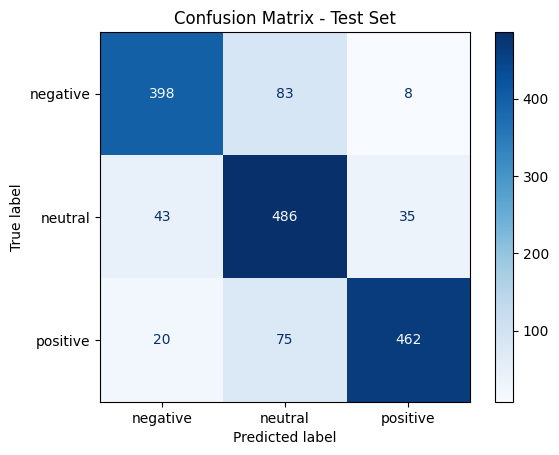

In [42]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Test Set")
plt.show()

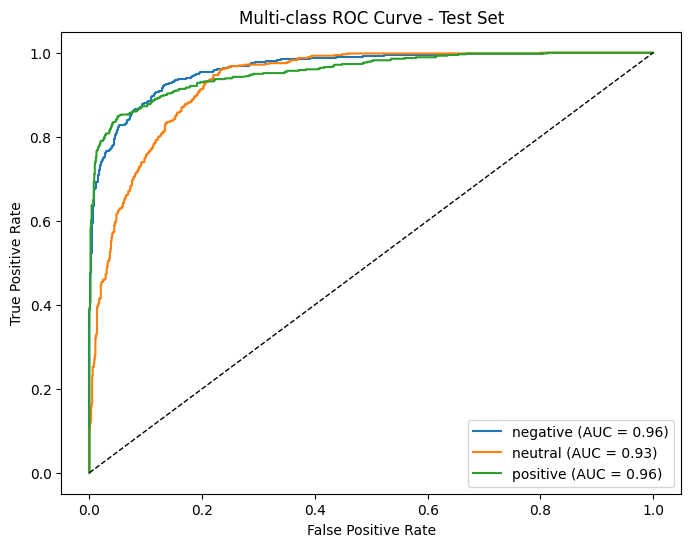

In [43]:
num_labels = len(le.classes_)
y_test_bin = label_binarize(all_labels, classes=range(num_labels))

final_model.eval()
all_scores = []

with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device)
        outputs = final_model(x)
        all_scores.extend(outputs.cpu().numpy())

all_scores = np.array(all_scores)

plt.figure(figsize=(8,6))
for i in range(num_labels):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve - Test Set")
plt.legend(loc="lower right")
plt.show()